In [3]:
import torch

In [24]:
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/epoch_40.pt', map_location=torch.device('cpu'))

In [25]:
print(check['optimizer_state_dict']['state'][0]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][1]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][2]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][3]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][4]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][5]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][6]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][7]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][8]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][9]['exp_avg'].shape)
print(check['optimizer_state_dict']['state'][10]['exp_avg'].shape)

torch.Size([50001, 650])
torch.Size([2600, 650])
torch.Size([2600, 650])
torch.Size([2600])
torch.Size([2600])
torch.Size([2600, 650])
torch.Size([2600, 650])
torch.Size([2600])
torch.Size([2600])
torch.Size([50001, 650])
torch.Size([50001])


- exp avg : direction : magnitude : m_{t}= beta_{1}*m_{t-1}+(1-beta_{1})*g_{t}
- exp avg square : magnitude : v_{t}= beta_{2}*v_{t-1}+(1-beta_{2})*(g_{t}**2)
- They're both momentum 

In [10]:
W_i_hh_l0, W_f_hh_l0, W_c_hh_l0, W_o_hh_l0 = check['optimizer_state_dict']['state'][2]['exp_avg'].chunk(4, dim=0)
W_i_ih_l0, W_f_ih_l0, W_c_ih_l0, W_o_ih_l0 = check['optimizer_state_dict']['state'][1]['exp_avg'].chunk(4, dim=0)

In [9]:
import os
import glob
import torch

# 1) find and sort your checkpoint files by epoch number
ckpt_dir = '/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam'
paths = glob.glob(os.path.join(ckpt_dir, '*.pt'))
# assume your files are named like 'epoch_40.pt'
paths = sorted(paths, key=lambda p: int(os.path.basename(p).split('_')[-1].split('.')[0]))
   # after you glob and sort:
paths = [p for p in paths 
        if not p.endswith("epoch_1_batch_0.pt")]

# 2) prepare containers for each gate’s moving‐average
moving_avgs = {
    'W_i_ih': [], 'W_f_ih': [], 'W_c_ih': [], 'W_o_ih': [],
    'W_i_hh': [], 'W_f_hh': [], 'W_c_hh': [], 'W_o_hh': [],
}

# 3) loop, load, chunk, and append
for p in paths:
    try:
        ckpt = torch.load(p, map_location="cpu")
    except Exception:
        print(f"⚠️  Skipping corrupt checkpoint {p}")
        continue
    # …rest of your logic…
    exp_avg_ih = ckpt['optimizer_state_dict']['state'][1]['exp_avg']  # weight_ih_l0
    exp_avg_hh = ckpt['optimizer_state_dict']['state'][2]['exp_avg']  # weight_hh_l0

    # chunk into (i, f, c, o)
    i_ih, f_ih, c_ih, o_ih = exp_avg_ih.chunk(4, dim=0)
    i_hh, f_hh, c_hh, o_hh = exp_avg_hh.chunk(4, dim=0)

    moving_avgs['W_i_ih'].append(i_ih)
    moving_avgs['W_f_ih'].append(f_ih)
    moving_avgs['W_c_ih'].append(c_ih)
    moving_avgs['W_o_ih'].append(o_ih)

    moving_avgs['W_i_hh'].append(i_hh)
    moving_avgs['W_f_hh'].append(f_hh)
    moving_avgs['W_c_hh'].append(c_hh)
    moving_avgs['W_o_hh'].append(o_hh)

# 4) stack each list into a single tensor
for name, lst in moving_avgs.items():
    # result[name].shape == (n_checkpoints, hidden_size, input_size)
    moving_avgs[name] = torch.stack(lst, dim=0)

# now moving_avgs['W_i_ih'] etc. are your per‐gate moving‐average tensors
for name, tensor in moving_avgs.items():
    print(f"{name}: {tensor.shape}")

W_i_ih: torch.Size([40, 650, 650])
W_f_ih: torch.Size([40, 650, 650])
W_c_ih: torch.Size([40, 650, 650])
W_o_ih: torch.Size([40, 650, 650])
W_i_hh: torch.Size([40, 650, 650])
W_f_hh: torch.Size([40, 650, 650])
W_c_hh: torch.Size([40, 650, 650])
W_o_hh: torch.Size([40, 650, 650])


In [10]:
def eig_values(W):
    eigenvals=[]
    for i in range(W.shape[0]):
        eig = torch.linalg.eigvals(W[i])
        eigenvals.append(eig)
    return torch.stack(eigenvals, dim=0)


In [11]:
W_i_ih_eig = eig_values(moving_avgs['W_i_ih'])
W_f_ih_eig = eig_values(moving_avgs['W_f_ih'])
W_c_ih_eig = eig_values(moving_avgs['W_c_ih'])
W_o_ih_eig = eig_values(moving_avgs['W_o_ih'])

W_i_hh_eig = eig_values(moving_avgs['W_i_hh'])
W_f_hh_eig = eig_values(moving_avgs['W_f_hh'])
W_c_hh_eig = eig_values(moving_avgs['W_c_hh'])
W_o_hh_eig = eig_values(moving_avgs['W_o_hh'])


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull
import seaborn as sns
import pandas as pd

def plot_3d_eigenvalue_evolution(eigenvalues_list, gate_names, epochs, figsize=(16, 14), top_n=10):
    """
    Plot 3D Adrian diagrams with enhanced visualization of eigenvalue shapes at each epoch
    
    Parameters:
    - eigenvalues_list: List of lists of eigenvalues per gate across epochs
    - gate_names: List of gate names
    - epochs: Array of epoch numbers
    - figsize: Figure size
    - top_n: Number of top eigenvalues to plot (selected by magnitude)
    """
    plt.ion()

    num_gates = len(eigenvalues_list)
    
    # Create a figure with 3D subplots
    fig = plt.figure(figsize=figsize)
    
    for gate_idx, gate_name in enumerate(gate_names):
        # Create a 3D subplot
        ax = fig.add_subplot(2, 2, gate_idx + 1, projection='3d')
        
        # Prepare colormap for epochs
        cmap = plt.cm.viridis
        norm = plt.Normalize(min(epochs), max(epochs))
        
        # For each epoch, plot the eigenvalues
        for epoch_idx, epoch in enumerate(epochs):
            eig_vals = eigenvalues_list[gate_idx][epoch_idx]
            
            # Select top_n eigenvalues by magnitude
            magnitudes = np.abs(eig_vals)
            top_indices = np.argsort(magnitudes)[-top_n:]  # Get indices of top_n largest magnitudes
            
            # Select only the top eigenvalues
            top_eig_vals = eig_vals[top_indices]
            
            real_parts = np.real(top_eig_vals)
            imag_parts = np.imag(top_eig_vals)
            # Create a time coordinate for all eigenvalues at this epoch
            time_coords = np.full_like(real_parts, epoch)
            
            # Plot eigenvalues as points in 3D space
            scatter = ax.scatter(
                real_parts, 
                imag_parts, 
                time_coords,
                c=[cmap(norm(epoch))] * len(top_eig_vals),
                alpha=0.8,
                s=60,  # Larger points for better visibility
                label=f'Epoch {epoch}'
            )
            
            # Enhanced visualization of the shape:
            # Method 1: Connect points in order of angle for a clean polygon
            angles = np.angle(top_eig_vals)
            sorted_indices = np.argsort(angles)
            
            # Create arrays for the sorted eigenvalues to make a closed polygon
            sorted_real = real_parts[sorted_indices]
            sorted_imag = imag_parts[sorted_indices]
            
            # Add the first point again to close the loop
            sorted_real = np.append(sorted_real, sorted_real[0])
            sorted_imag = np.append(sorted_imag, sorted_imag[0])
            time_array = np.full_like(sorted_real, epoch)
            
            # Draw the polygon connecting eigenvalues
            ax.plot(
                sorted_real,
                sorted_imag,
                time_array,
                color=cmap(norm(epoch)),
                alpha=0.6,
                linewidth=2.5
            )
            
            # Method 2: Fill the polygon with semi-transparent surface for better shape visualization
            # Only do this if we have at least 3 eigenvalues (required for a polygon)
            if len(top_eig_vals) >= 3:
                # Create a polygon patch
                polygon = np.column_stack((sorted_real[:-1], sorted_imag[:-1]))  # Remove duplicate point
                
                try:
                    # Try to create a convex hull for more stable surface plotting
                    hull = ConvexHull(polygon)
                    # Create a surface using the hull vertices
                    for simplex in hull.simplices:
                        x = polygon[simplex, 0]
                        y = polygon[simplex, 1]
                        z = np.full_like(x, epoch)
                        ax.plot_trisurf(x, y, z, color=cmap(norm(epoch)), alpha=0.5)
                except:
                    # Fall back to simple polygon if convex hull fails
                    ax.plot_trisurf(
                        sorted_real[:-1],  # Exclude the duplicate point
                        sorted_imag[:-1], 
                        np.full_like(sorted_real[:-1], epoch),
                        color=cmap(norm(epoch)), 
                        alpha=0.2
                    )
        
        # Add unit circle at each time step
        theta = np.linspace(0, 2*np.pi, 100)
        for epoch in epochs:
            x = np.cos(theta)
            y = np.sin(theta)
            z = np.full_like(theta, epoch)
            ax.plot(x, y, z, 'r--', alpha=0.5, linewidth=1.5)
        
        # Set labels and title
        ax.set_xlabel('Real Part', fontsize=12)
        ax.set_ylabel('Imaginary Part', fontsize=12)
        ax.set_zlabel('Epoch', fontsize=12)
        ax.set_title(f'{gate_name} - Eigenvalue Shape Evolution', fontsize=14, fontweight='bold')
        
        # Set equal aspect ratio for x and y to ensure circle looks like a circle
        # This makes the curvature more apparent
        ax.set_box_aspect([1, 1, 1.5])
        
        # Add grid for better visualization
        ax.grid(True, alpha=0.3)
        
        # Add a colorbar to indicate epochs
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, label='Epoch')
    
    plt.tight_layout()

    # Enable rotation and view adjustment
    for ax in fig.get_axes():
        if hasattr(ax, 'view_init'):  # Check if it's a 3D axis
            ax.view_init(elev=0, azim=45)  # Set initial viewing angle
        
    return fig

In [13]:
eigenvalues_ih_list = [
    W_i_ih_eig,  # Layer 1: Input gate (ih)
    W_f_ih_eig,  # Layer 2: Forget gate (ih)
    W_c_ih_eig,  # Layer 3: Cell gate (ih)
    W_o_ih_eig,  # Layer 4: Output gate (ih)
]
eigenvalues_hh_list = [
    W_i_hh_eig,  # Layer 5: Input gate (hh)
    W_f_hh_eig,  # Layer 6: Forget gate (hh)
    W_c_hh_eig,  # Layer 7: Cell gate (hh)
    W_o_hh_eig   # Layer 8: Output gate (hh)
]

# Create gate names for the plot
gate_names_ih = [
    'Input Gate (ih)',
    'Forget Gate (ih)',
    'Cell Gate (ih)',
    'Output Gate (ih)',
]
gate_names_hh=[
    'Input Gate (hh)',
    'Forget Gate (hh)',
    'Cell Gate (hh)',
    'Output Gate (hh)'
]

# Create epoch numbers
epochs = np.arange(1, len(W_i_ih_eig) + 1)

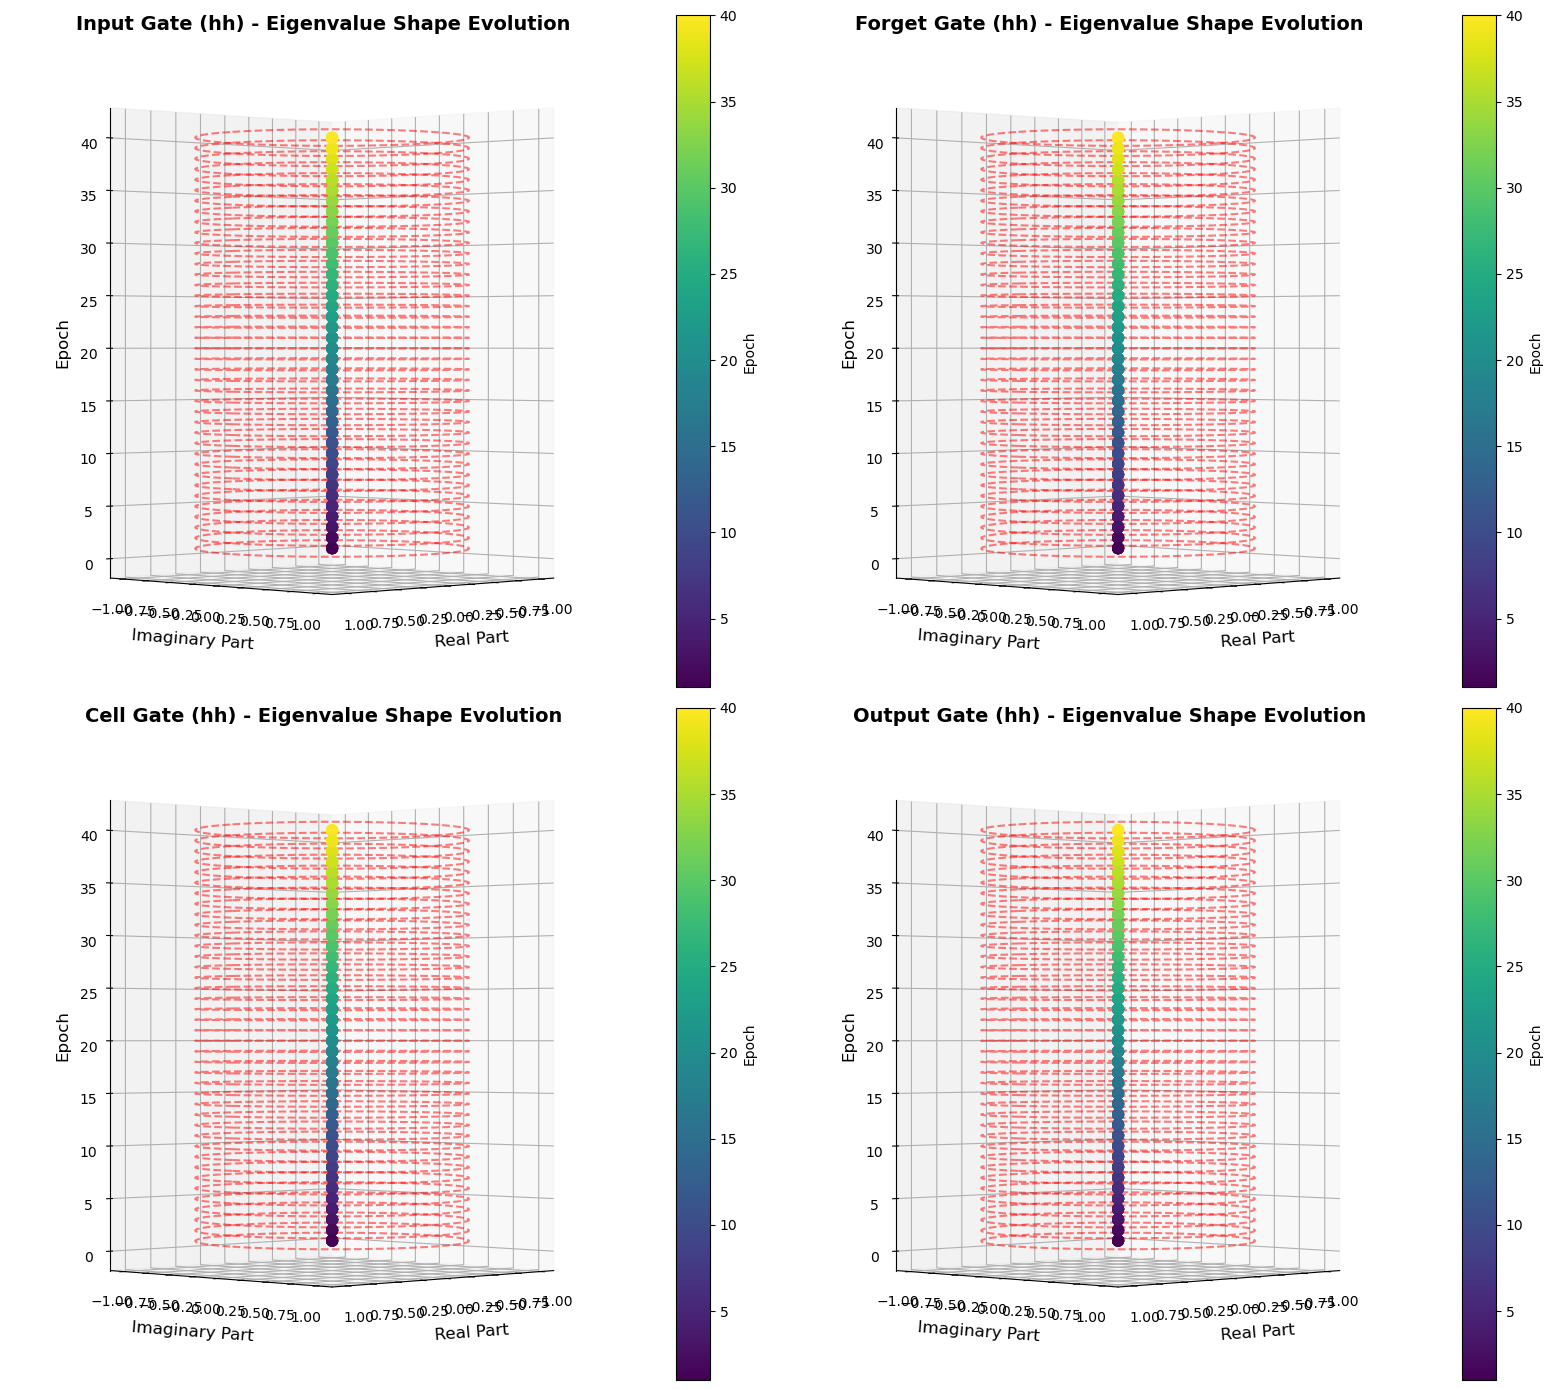

In [14]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_hh_list, gate_names_hh, epochs, top_n=10)


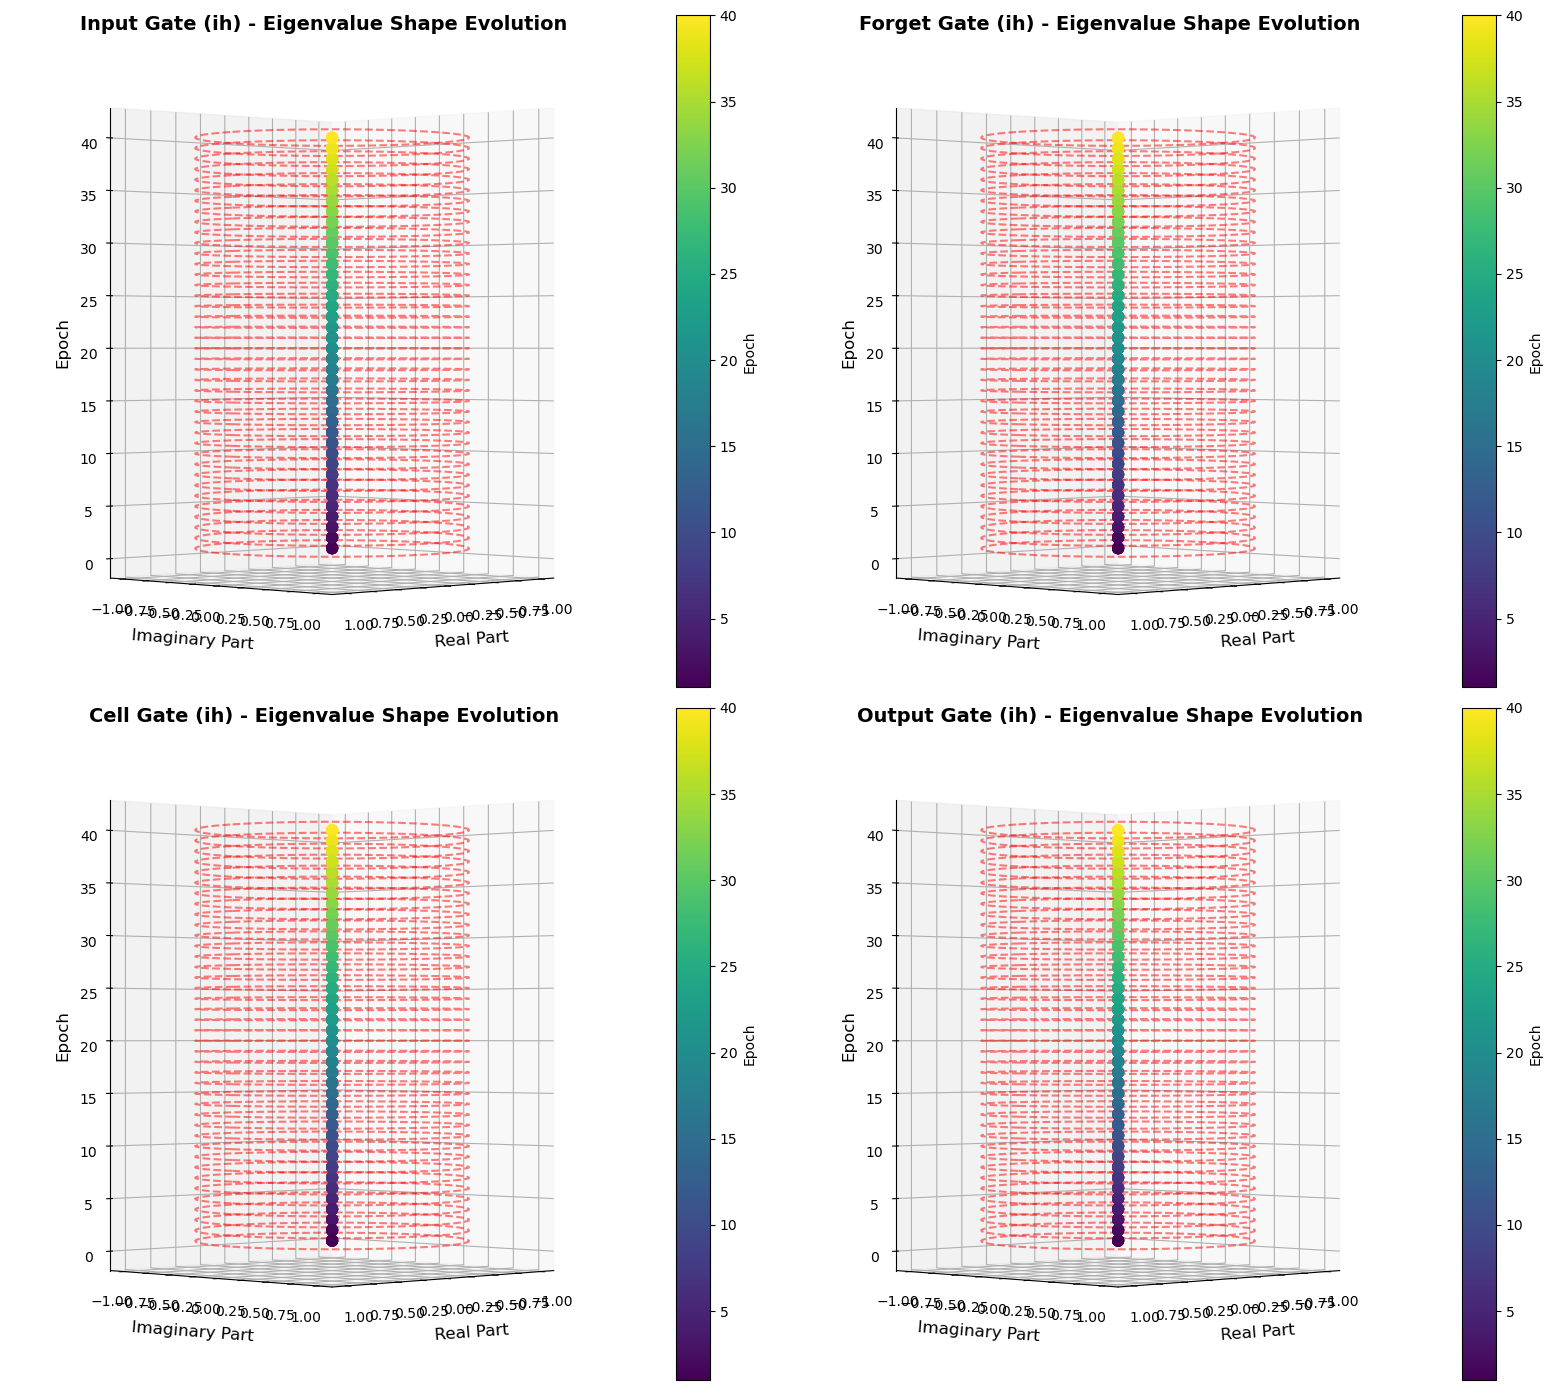

In [15]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_ih_list, gate_names_ih, epochs, top_n=10)


In [16]:
def plot_matrix_norms(weight_tensors, figsize=(16, 12)):
    """
    Plot Frobenius norms of the matrices across time
    
    Parameters:
    - weight_tensors: Dictionary of weight tensors across time
    - figsize: Figure size for the plot
    """
    plt.ion()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    
    # Prepare colormap
    cmap = plt.cm.viridis
    colors = [cmap(i/4) for i in range(4)]  # 4 different colors for 4 gates
    
    # Separate input-to-hidden and hidden-to-hidden gates
    ih_gates = ['W_i_ih', 'W_f_ih', 'W_c_ih', 'W_o_ih']
    hh_gates = ['W_i_hh', 'W_f_hh', 'W_c_hh', 'W_o_hh']
    
    # Plot input-to-hidden gates
    for i, gate_name in enumerate(ih_gates):
        tensors = weight_tensors[gate_name]
        norms = []
        for j in range(tensors.shape[0]):
            # Compute Frobenius norm of the matrix itself
            frob_norm = torch.norm(tensors[j], p='fro').item()
            norms.append(frob_norm)
        
        epochs = np.arange(len(norms))
        ax1.plot(epochs, norms, 
                label=gate_name,
                color=colors[i],
                linewidth=2)
    
    # Plot hidden-to-hidden gates
    for i, gate_name in enumerate(hh_gates):
        tensors = weight_tensors[gate_name]
        norms = []
        for j in range(tensors.shape[0]):
            # Compute Frobenius norm of the matrix itself
            frob_norm = torch.norm(tensors[j], p='fro').item()
            norms.append(frob_norm)
        
        epochs = np.arange(len(norms))
        ax2.plot(epochs, norms, 
                label=gate_name,
                color=colors[i],
                linewidth=2)
    
    # Customize plots
    for ax, title in [(ax1, 'Input-to-Hidden Gates'), (ax2, 'Hidden-to-Hidden Gates')]:
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Frobenius Norm')
        ax.set_title(title)
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    return fig



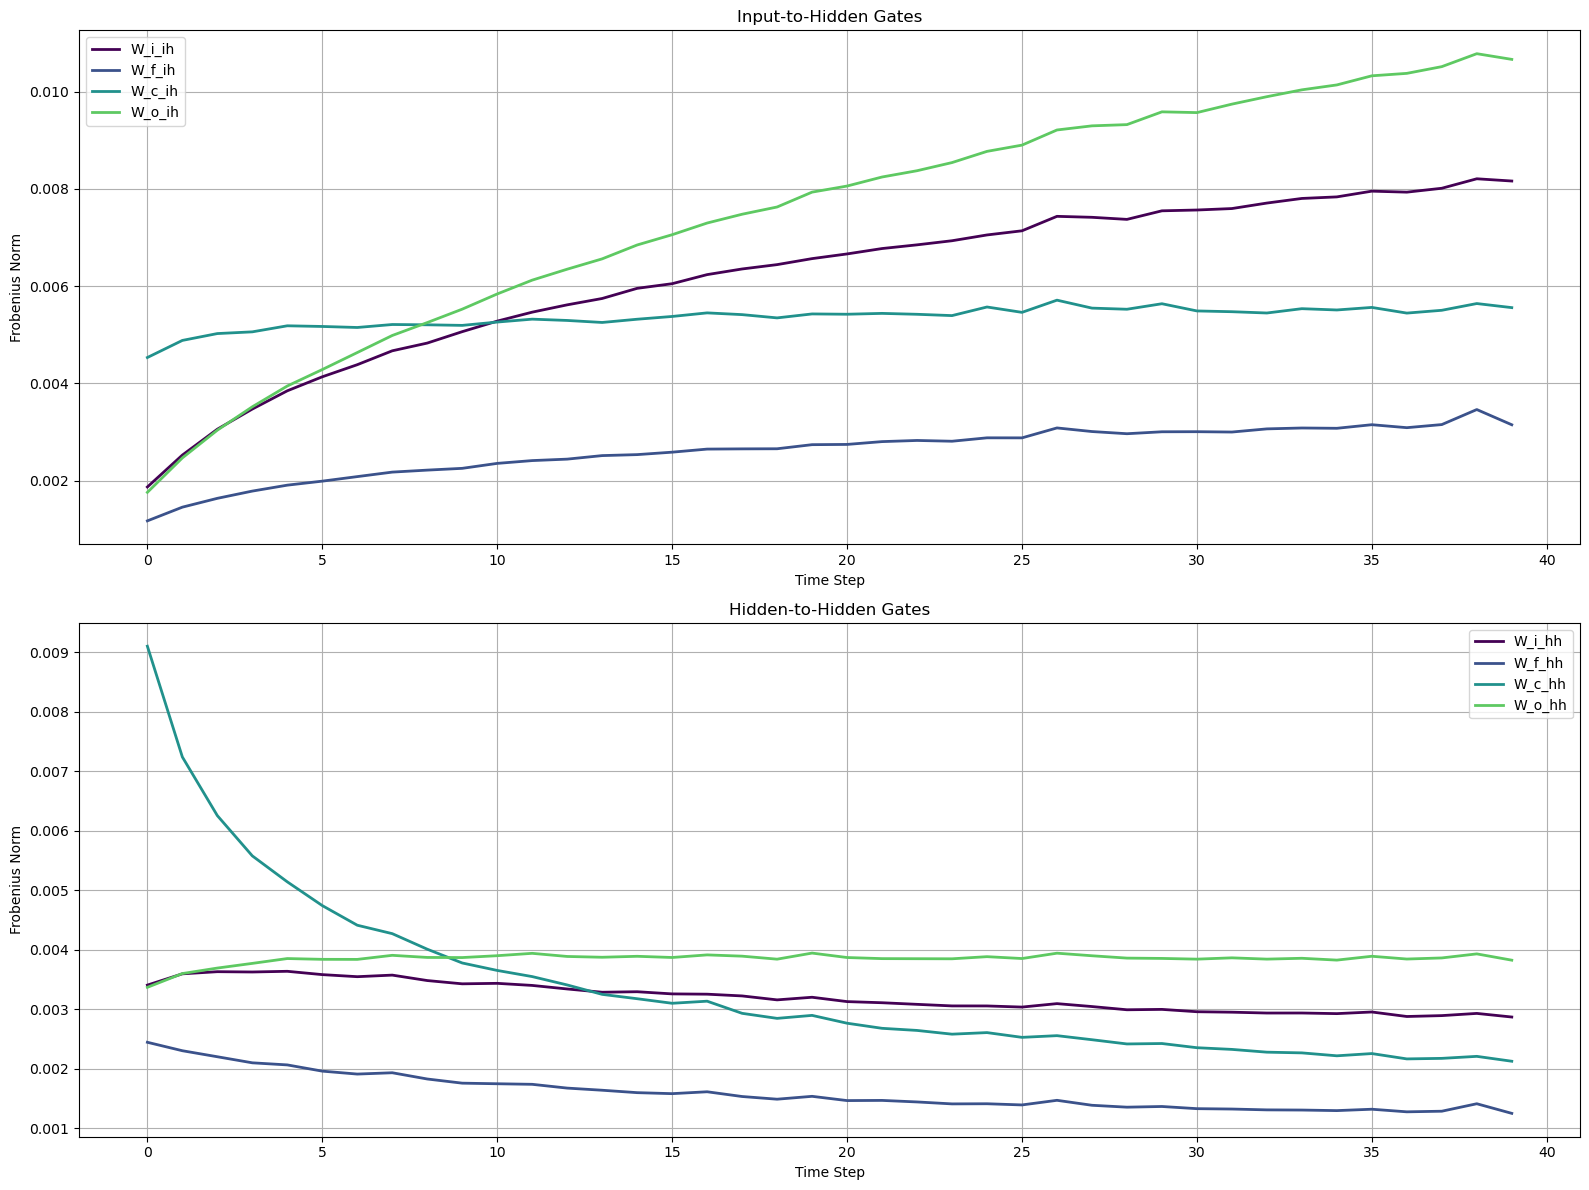

In [17]:
fig = plot_matrix_norms(moving_avgs)

## Exp avg squared

In [18]:
import os
import glob
import torch

# 1) find and sort your checkpoint files by epoch number
ckpt_dir = '/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam'
paths = glob.glob(os.path.join(ckpt_dir, '*.pt'))
# assume your files are named like 'epoch_40.pt'
paths = sorted(paths, key=lambda p: int(os.path.basename(p).split('_')[-1].split('.')[0]))
   # after you glob and sort:
paths = [p for p in paths 
        if not p.endswith("epoch_1_batch_0.pt")]

# 2) prepare containers for each gate’s moving‐average
exp_avg_sq = {
    'W_i_ih': [], 'W_f_ih': [], 'W_c_ih': [], 'W_o_ih': [],
    'W_i_hh': [], 'W_f_hh': [], 'W_c_hh': [], 'W_o_hh': [],
}

# 3) loop, load, chunk, and append
for p in paths:
    try:
        ckpt = torch.load(p, map_location="cpu")
    except Exception:
        print(f"⚠️  Skipping corrupt checkpoint {p}")
        continue
    # …rest of your logic…
    exp_avg_ih = ckpt['optimizer_state_dict']['state'][1]['exp_avg_sq']  # weight_ih_l0
    exp_avg_hh = ckpt['optimizer_state_dict']['state'][2]['exp_avg_sq']  # weight_hh_l0

    # chunk into (i, f, c, o)
    i_ih, f_ih, c_ih, o_ih = exp_avg_ih.chunk(4, dim=0)
    i_hh, f_hh, c_hh, o_hh = exp_avg_hh.chunk(4, dim=0)

    exp_avg_sq['W_i_ih'].append(i_ih)
    exp_avg_sq['W_f_ih'].append(f_ih)
    exp_avg_sq['W_c_ih'].append(c_ih)
    exp_avg_sq['W_o_ih'].append(o_ih)

    exp_avg_sq['W_i_hh'].append(i_hh)
    exp_avg_sq['W_f_hh'].append(f_hh)
    exp_avg_sq['W_c_hh'].append(c_hh)
    exp_avg_sq['W_o_hh'].append(o_hh)

# 4) stack each list into a single tensor
for name, lst in exp_avg_sq.items():
    # result[name].shape == (n_checkpoints, hidden_size, input_size)
    exp_avg_sq[name] = torch.stack(lst, dim=0)

# now exp_avg_sq['W_i_ih'] etc. are your per‐gate moving‐average tensors
for name, tensor in exp_avg_sq.items():
    print(f"{name}: {tensor.shape}")

W_i_ih: torch.Size([40, 650, 650])
W_f_ih: torch.Size([40, 650, 650])
W_c_ih: torch.Size([40, 650, 650])
W_o_ih: torch.Size([40, 650, 650])
W_i_hh: torch.Size([40, 650, 650])
W_f_hh: torch.Size([40, 650, 650])
W_c_hh: torch.Size([40, 650, 650])
W_o_hh: torch.Size([40, 650, 650])


In [19]:
W_i_ih_eig = eig_values(exp_avg_sq['W_i_ih'])
W_f_ih_eig = eig_values(exp_avg_sq['W_f_ih'])
W_c_ih_eig = eig_values(exp_avg_sq['W_c_ih'])
W_o_ih_eig = eig_values(exp_avg_sq['W_o_ih'])

W_i_hh_eig = eig_values(exp_avg_sq['W_i_hh'])
W_f_hh_eig = eig_values(exp_avg_sq['W_f_hh'])
W_c_hh_eig = eig_values(exp_avg_sq['W_c_hh'])
W_o_hh_eig = eig_values(exp_avg_sq['W_o_hh'])


In [20]:
eigenvalues_ih_list = [
    W_i_ih_eig,  # Layer 1: Input gate (ih)
    W_f_ih_eig,  # Layer 2: Forget gate (ih)
    W_c_ih_eig,  # Layer 3: Cell gate (ih)
    W_o_ih_eig,  # Layer 4: Output gate (ih)
]
eigenvalues_hh_list = [
    W_i_hh_eig,  # Layer 5: Input gate (hh)
    W_f_hh_eig,  # Layer 6: Forget gate (hh)
    W_c_hh_eig,  # Layer 7: Cell gate (hh)
    W_o_hh_eig   # Layer 8: Output gate (hh)
]

# Create gate names for the plot
gate_names_ih = [
    'Input Gate (ih)',
    'Forget Gate (ih)',
    'Cell Gate (ih)',
    'Output Gate (ih)',
]
gate_names_hh=[
    'Input Gate (hh)',
    'Forget Gate (hh)',
    'Cell Gate (hh)',
    'Output Gate (hh)'
]

# Create epoch numbers
epochs = np.arange(1, len(W_i_ih_eig) + 1)

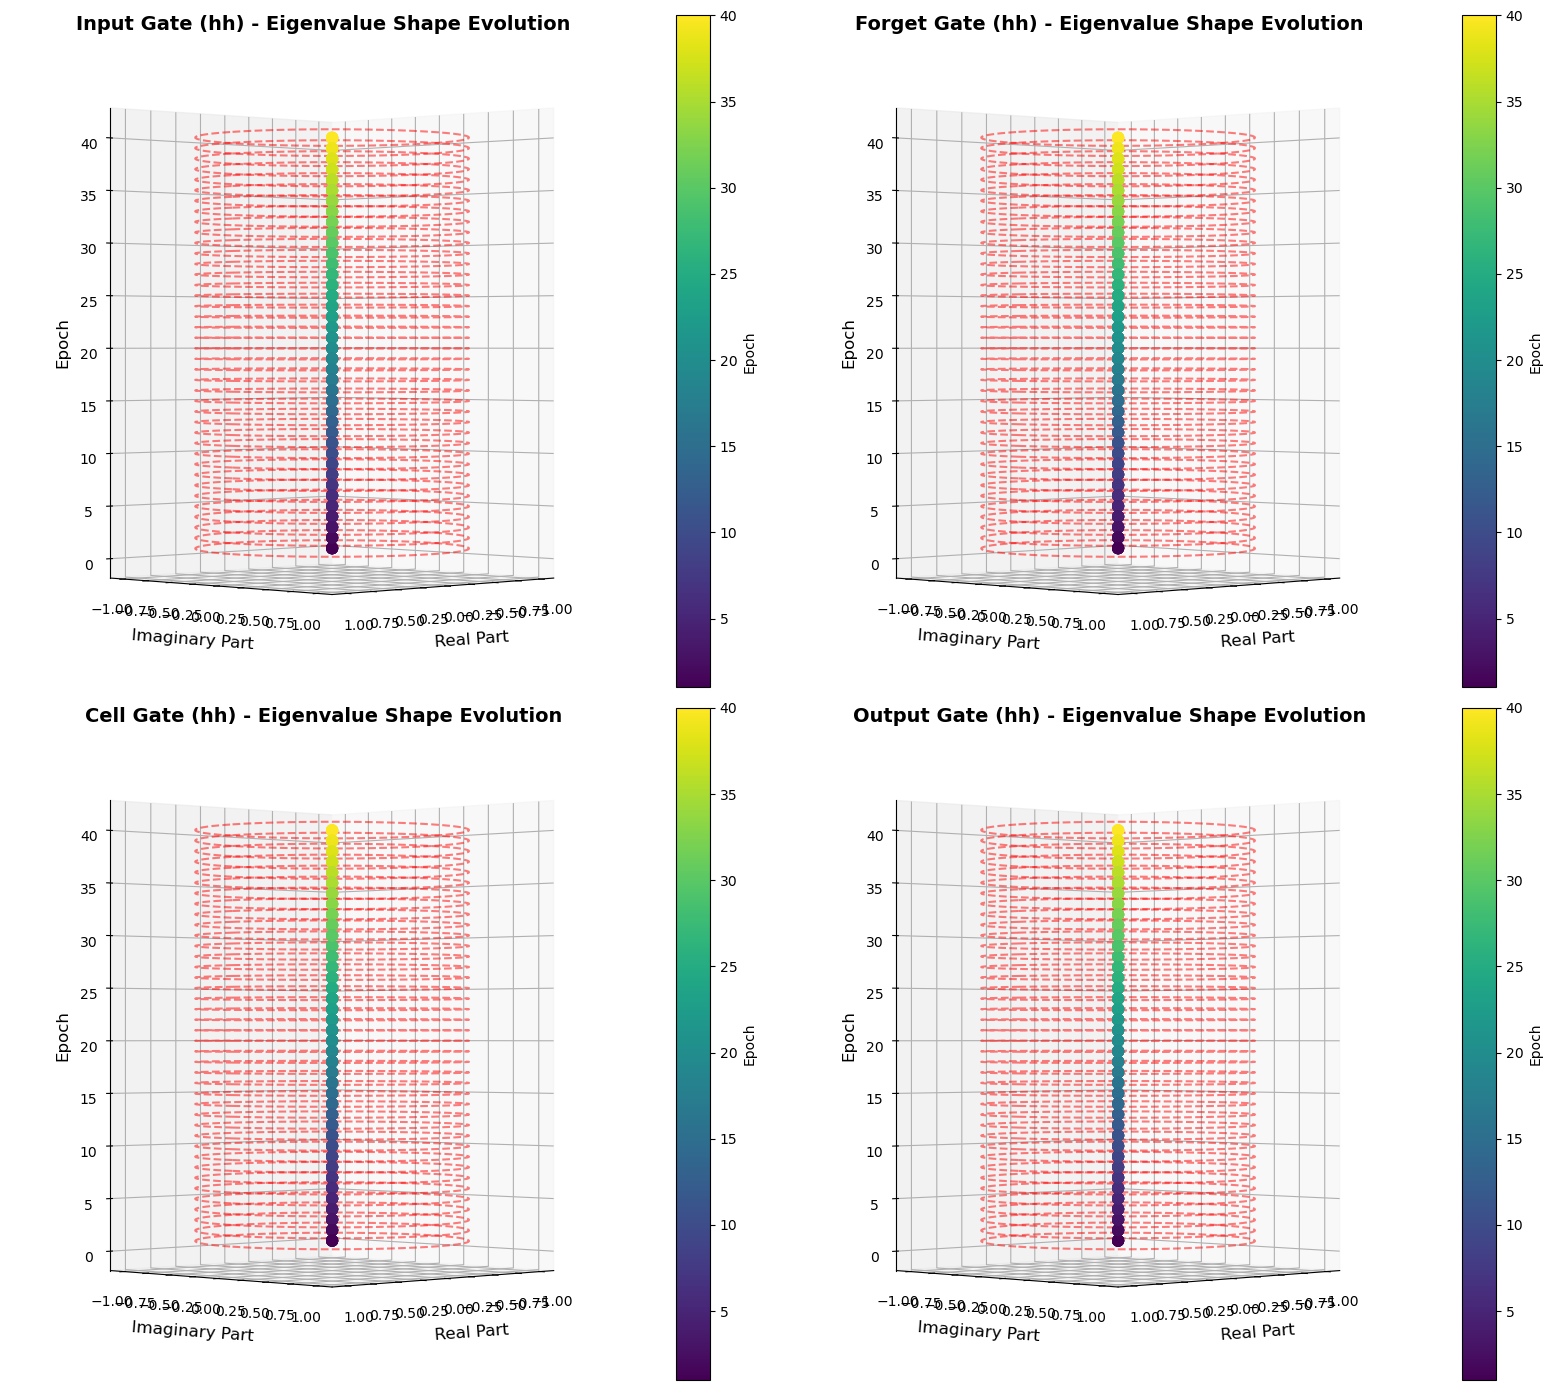

In [21]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_hh_list, gate_names_hh, epochs, top_n=10)


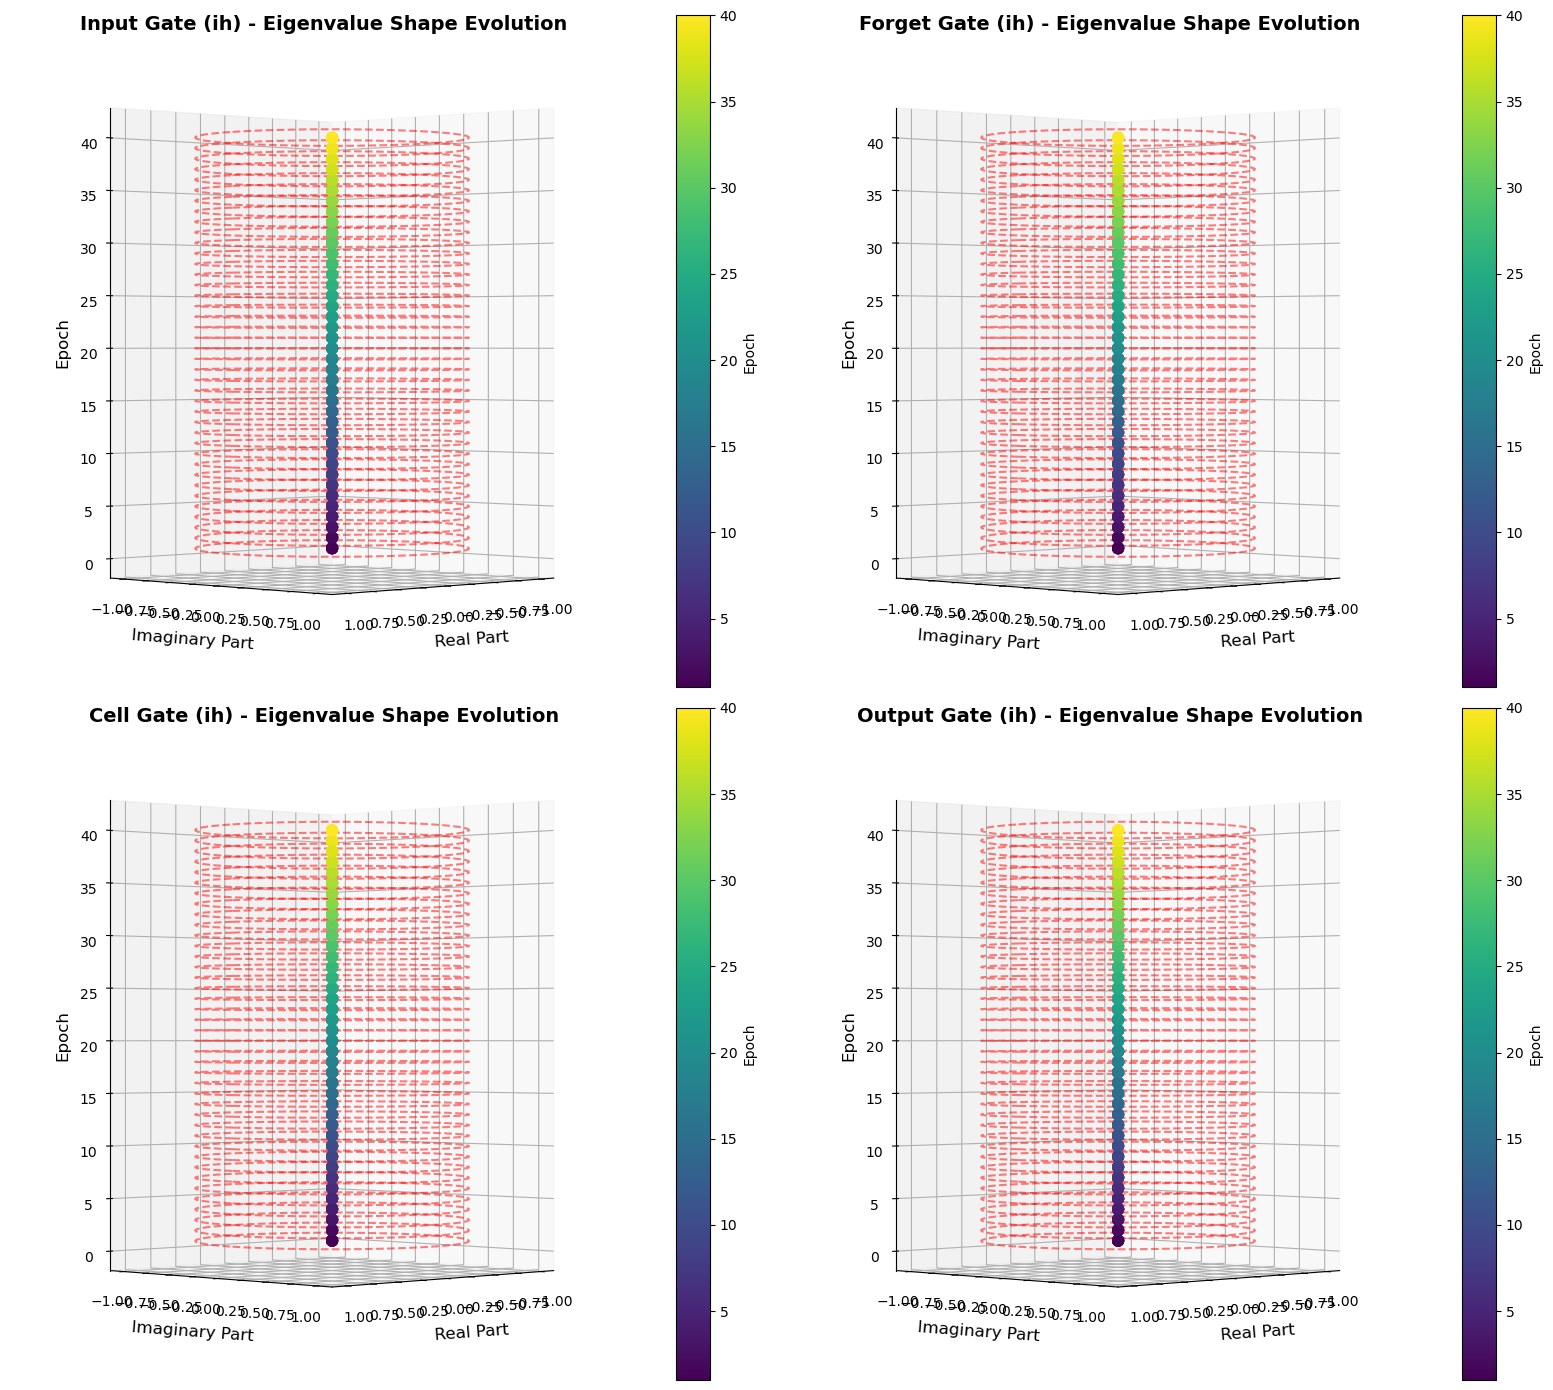

In [22]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_ih_list, gate_names_ih, epochs, top_n=10)


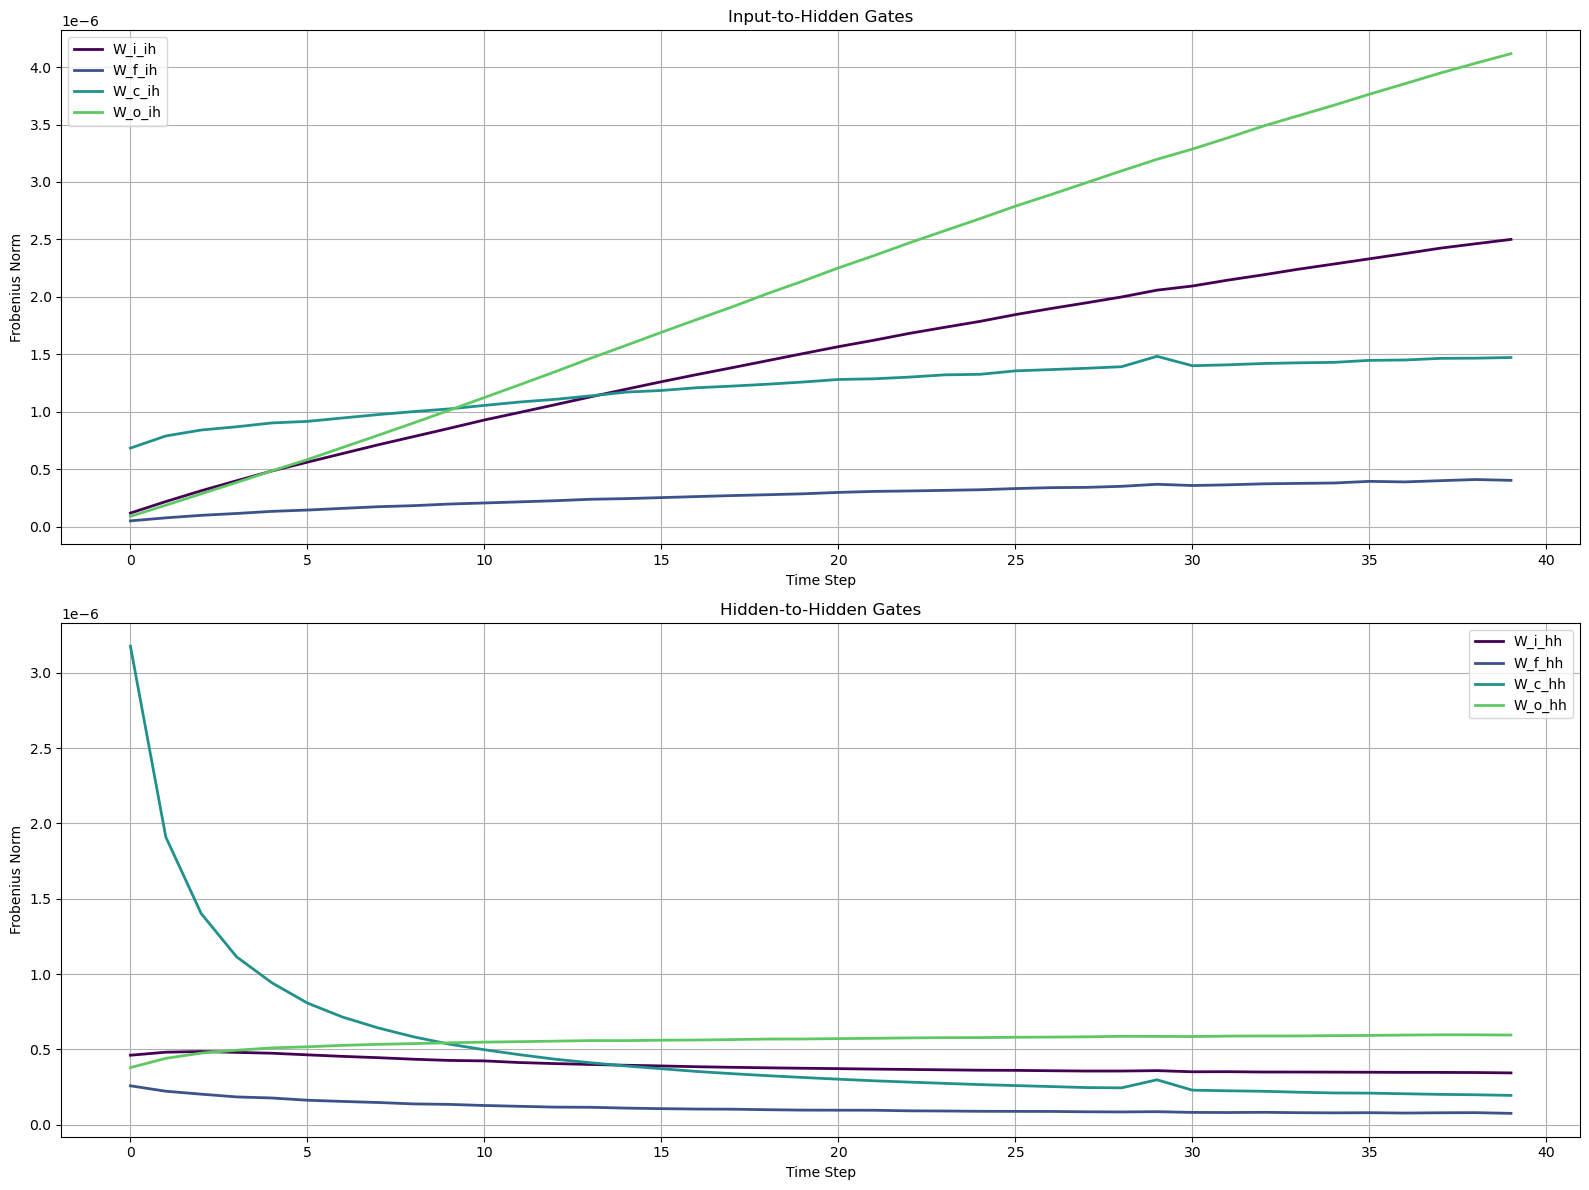

In [23]:
fig = plot_matrix_norms(exp_avg_sq)

# Layer 2 weight analysis

## Exponential moving average

In [26]:
import os
import glob
import torch

# 1) find and sort your checkpoint files by epoch number
ckpt_dir = '/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam'
paths = glob.glob(os.path.join(ckpt_dir, '*.pt'))
# assume your files are named like 'epoch_40.pt'
paths = sorted(paths, key=lambda p: int(os.path.basename(p).split('_')[-1].split('.')[0]))
   # after you glob and sort:
paths = [p for p in paths 
        if not p.endswith("epoch_1_batch_0.pt")]

# 2) prepare containers for each gate’s moving‐average
moving_avgs = {
    'W_i_ih': [], 'W_f_ih': [], 'W_c_ih': [], 'W_o_ih': [],
    'W_i_hh': [], 'W_f_hh': [], 'W_c_hh': [], 'W_o_hh': [],
}

# 3) loop, load, chunk, and append
for p in paths:
    try:
        ckpt = torch.load(p, map_location="cpu")
    except Exception:
        print(f"⚠️  Skipping corrupt checkpoint {p}")
        continue
    # …rest of your logic…
    exp_avg_ih = ckpt['optimizer_state_dict']['state'][5]['exp_avg']  # weight_ih_l0
    exp_avg_hh = ckpt['optimizer_state_dict']['state'][6]['exp_avg']  # weight_hh_l0

    # chunk into (i, f, c, o)
    i_ih, f_ih, c_ih, o_ih = exp_avg_ih.chunk(4, dim=0)
    i_hh, f_hh, c_hh, o_hh = exp_avg_hh.chunk(4, dim=0)

    moving_avgs['W_i_ih'].append(i_ih)
    moving_avgs['W_f_ih'].append(f_ih)
    moving_avgs['W_c_ih'].append(c_ih)
    moving_avgs['W_o_ih'].append(o_ih)

    moving_avgs['W_i_hh'].append(i_hh)
    moving_avgs['W_f_hh'].append(f_hh)
    moving_avgs['W_c_hh'].append(c_hh)
    moving_avgs['W_o_hh'].append(o_hh)

# 4) stack each list into a single tensor
for name, lst in moving_avgs.items():
    # result[name].shape == (n_checkpoints, hidden_size, input_size)
    moving_avgs[name] = torch.stack(lst, dim=0)

# now moving_avgs['W_i_ih'] etc. are your per‐gate moving‐average tensors
for name, tensor in moving_avgs.items():
    print(f"{name}: {tensor.shape}")

W_i_ih: torch.Size([40, 650, 650])
W_f_ih: torch.Size([40, 650, 650])
W_c_ih: torch.Size([40, 650, 650])
W_o_ih: torch.Size([40, 650, 650])
W_i_hh: torch.Size([40, 650, 650])
W_f_hh: torch.Size([40, 650, 650])
W_c_hh: torch.Size([40, 650, 650])
W_o_hh: torch.Size([40, 650, 650])


In [27]:
W_i_ih_eig = eig_values(moving_avgs['W_i_ih'])
W_f_ih_eig = eig_values(moving_avgs['W_f_ih'])
W_c_ih_eig = eig_values(moving_avgs['W_c_ih'])
W_o_ih_eig = eig_values(moving_avgs['W_o_ih'])

W_i_hh_eig = eig_values(moving_avgs['W_i_hh'])
W_f_hh_eig = eig_values(moving_avgs['W_f_hh'])
W_c_hh_eig = eig_values(moving_avgs['W_c_hh'])
W_o_hh_eig = eig_values(moving_avgs['W_o_hh'])


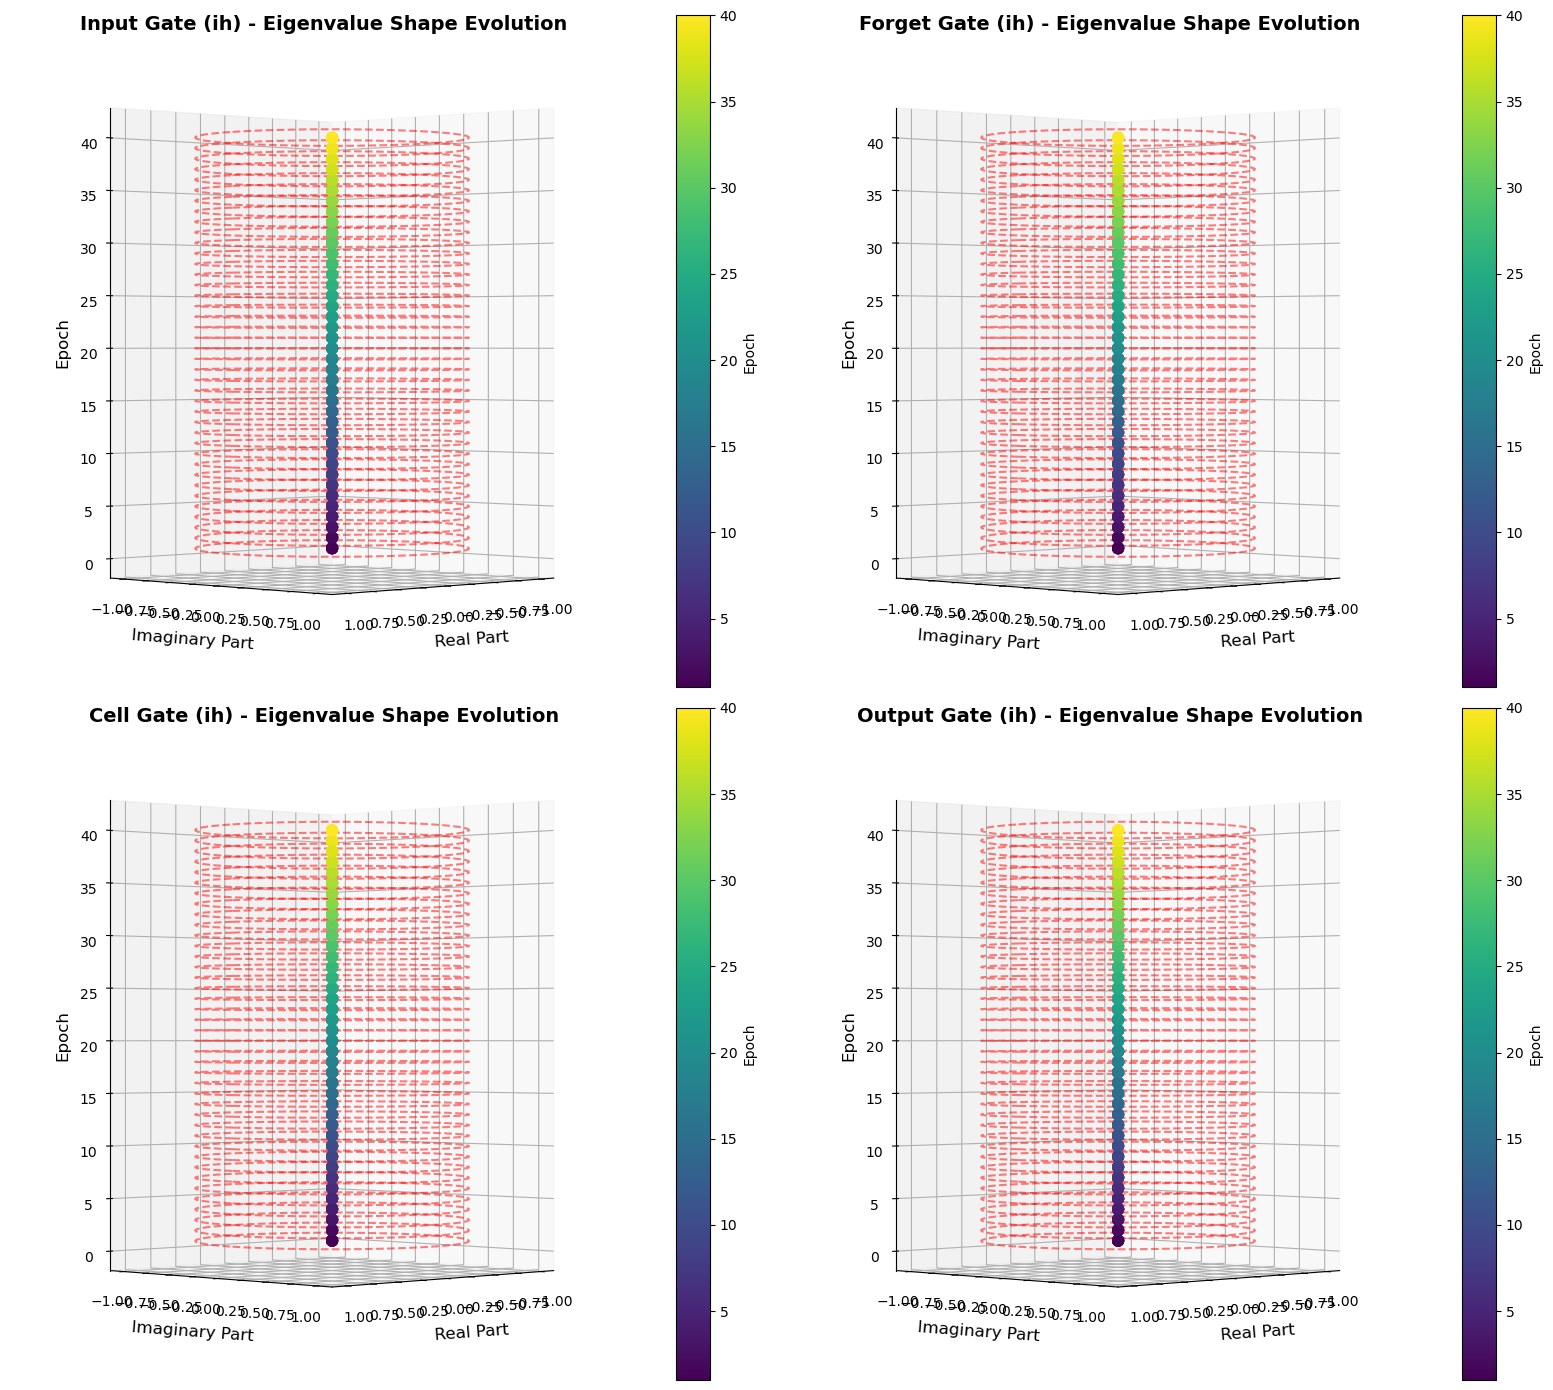

In [28]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_ih_list, gate_names_ih, epochs, top_n=10)


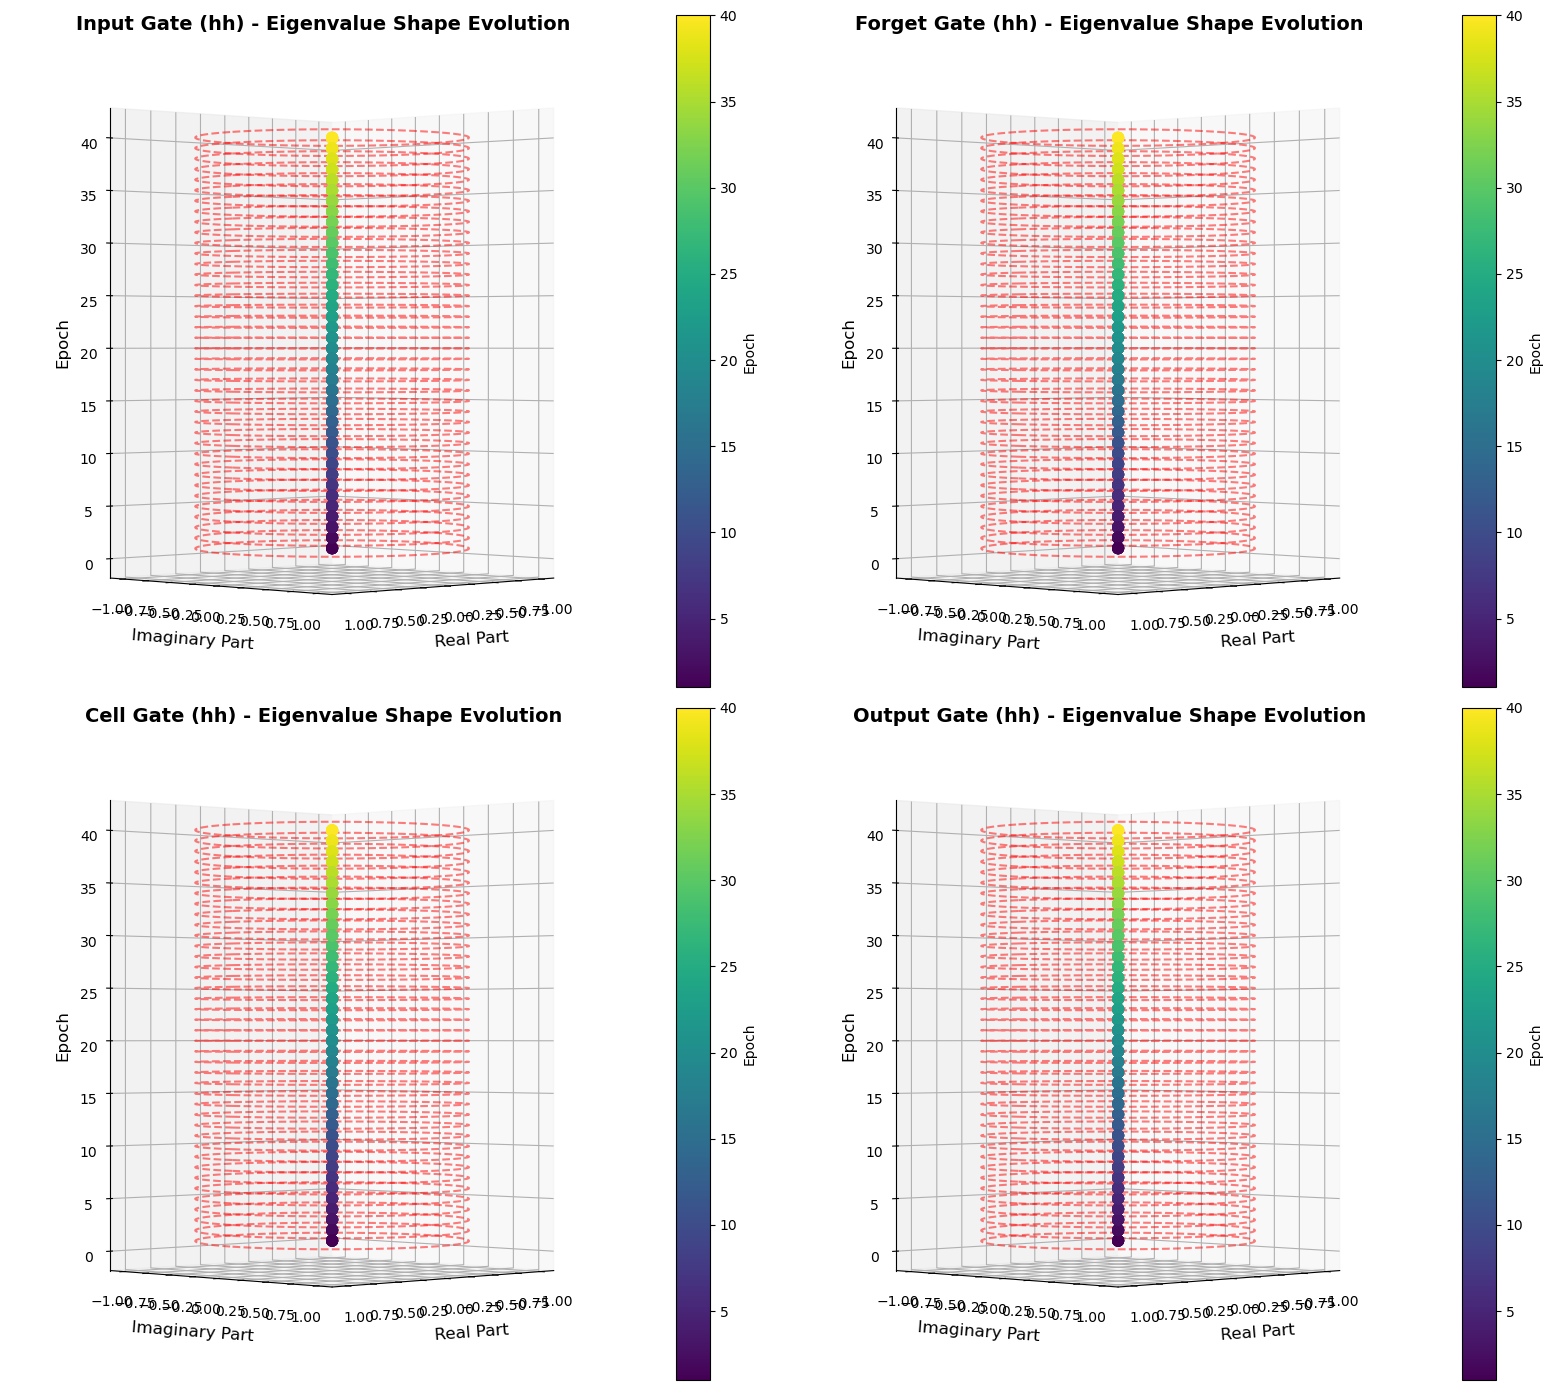

In [29]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_hh_list, gate_names_hh, epochs, top_n=10)


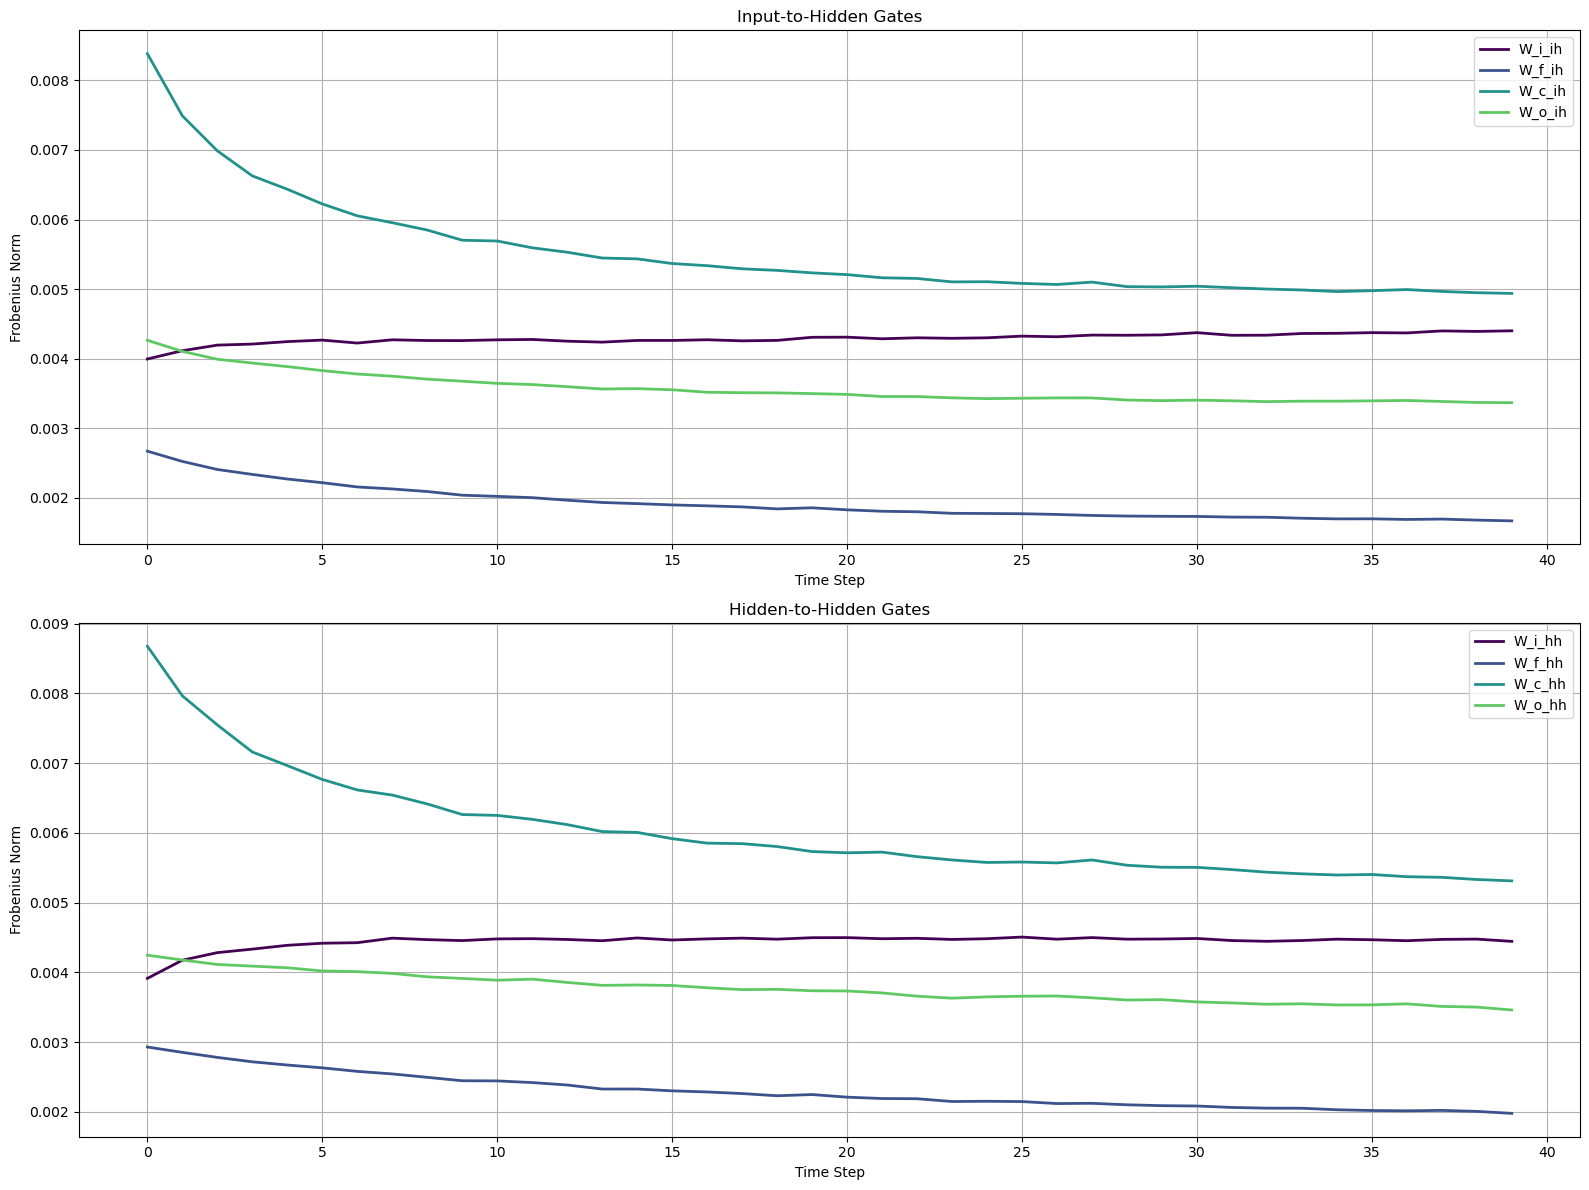

In [30]:
fig = plot_matrix_norms(moving_avgs)

## Exponential moving average squared

In [38]:
import os
import glob
import torch

# 1) find and sort your checkpoint files by epoch number
ckpt_dir = '/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam'
paths = glob.glob(os.path.join(ckpt_dir, '*.pt'))
# assume your files are named like 'epoch_40.pt'
paths = sorted(paths, key=lambda p: int(os.path.basename(p).split('_')[-1].split('.')[0]))
   # after you glob and sort:
paths = [p for p in paths 
        if not p.endswith("epoch_1_batch_0.pt")]

# 2) prepare containers for each gate’s moving‐average
exp_avg_sq = {
    'W_i_ih': [], 'W_f_ih': [], 'W_c_ih': [], 'W_o_ih': [],
    'W_i_hh': [], 'W_f_hh': [], 'W_c_hh': [], 'W_o_hh': [],
}

# 3) loop, load, chunk, and append
for p in paths:
    try:
        ckpt = torch.load(p, map_location="cpu")
    except Exception:
        print(f"⚠️  Skipping corrupt checkpoint {p}")
        continue
    # …rest of your logic…
    exp_avg_ih = ckpt['optimizer_state_dict']['state'][5]['exp_avg_sq']  # weight_ih_l0
    exp_avg_hh = ckpt['optimizer_state_dict']['state'][6]['exp_avg_sq']  # weight_hh_l0

    # chunk into (i, f, c, o)
    i_ih, f_ih, c_ih, o_ih = exp_avg_ih.chunk(4, dim=0)
    i_hh, f_hh, c_hh, o_hh = exp_avg_hh.chunk(4, dim=0)

    exp_avg_sq['W_i_ih'].append(i_ih)
    exp_avg_sq['W_f_ih'].append(f_ih)
    exp_avg_sq['W_c_ih'].append(c_ih)
    exp_avg_sq['W_o_ih'].append(o_ih)

    exp_avg_sq['W_i_hh'].append(i_hh)
    exp_avg_sq['W_f_hh'].append(f_hh)
    exp_avg_sq['W_c_hh'].append(c_hh)
    exp_avg_sq['W_o_hh'].append(o_hh)

# 4) stack each list into a single tensor
for name, lst in exp_avg_sq.items():
    # result[name].shape == (n_checkpoints, hidden_size, input_size)
    exp_avg_sq[name] = torch.stack(lst, dim=0)

# now exp_avg_sq['W_i_ih'] etc. are your per‐gate moving‐average tensors
for name, tensor in exp_avg_sq.items():
    print(f"{name}: {tensor.shape}")

W_i_ih: torch.Size([40, 650, 650])
W_f_ih: torch.Size([40, 650, 650])
W_c_ih: torch.Size([40, 650, 650])
W_o_ih: torch.Size([40, 650, 650])
W_i_hh: torch.Size([40, 650, 650])
W_f_hh: torch.Size([40, 650, 650])
W_c_hh: torch.Size([40, 650, 650])
W_o_hh: torch.Size([40, 650, 650])


In [39]:
W_i_ih_eig = eig_values(exp_avg_sq['W_i_ih'])
W_f_ih_eig = eig_values(exp_avg_sq['W_f_ih'])
W_c_ih_eig = eig_values(exp_avg_sq['W_c_ih'])
W_o_ih_eig = eig_values(exp_avg_sq['W_o_ih'])

W_i_hh_eig = eig_values(exp_avg_sq['W_i_hh'])
W_f_hh_eig = eig_values(exp_avg_sq['W_f_hh'])
W_c_hh_eig = eig_values(exp_avg_sq['W_c_hh'])
W_o_hh_eig = eig_values(exp_avg_sq['W_o_hh'])


In [40]:
eigenvalues_ih_list = [
    W_i_ih_eig,  # Layer 1: Input gate (ih)
    W_f_ih_eig,  # Layer 2: Forget gate (ih)
    W_c_ih_eig,  # Layer 3: Cell gate (ih)
    W_o_ih_eig,  # Layer 4: Output gate (ih)
]
eigenvalues_hh_list = [
    W_i_hh_eig,  # Layer 5: Input gate (hh)
    W_f_hh_eig,  # Layer 6: Forget gate (hh)
    W_c_hh_eig,  # Layer 7: Cell gate (hh)
    W_o_hh_eig   # Layer 8: Output gate (hh)
]

# Create gate names for the plot
gate_names_ih = [
    'Input Gate (ih)',
    'Forget Gate (ih)',
    'Cell Gate (ih)',
    'Output Gate (ih)',
]
gate_names_hh=[
    'Input Gate (hh)',
    'Forget Gate (hh)',
    'Cell Gate (hh)',
    'Output Gate (hh)'
]

# Create epoch numbers
epochs = np.arange(1, len(W_i_ih_eig) + 1)

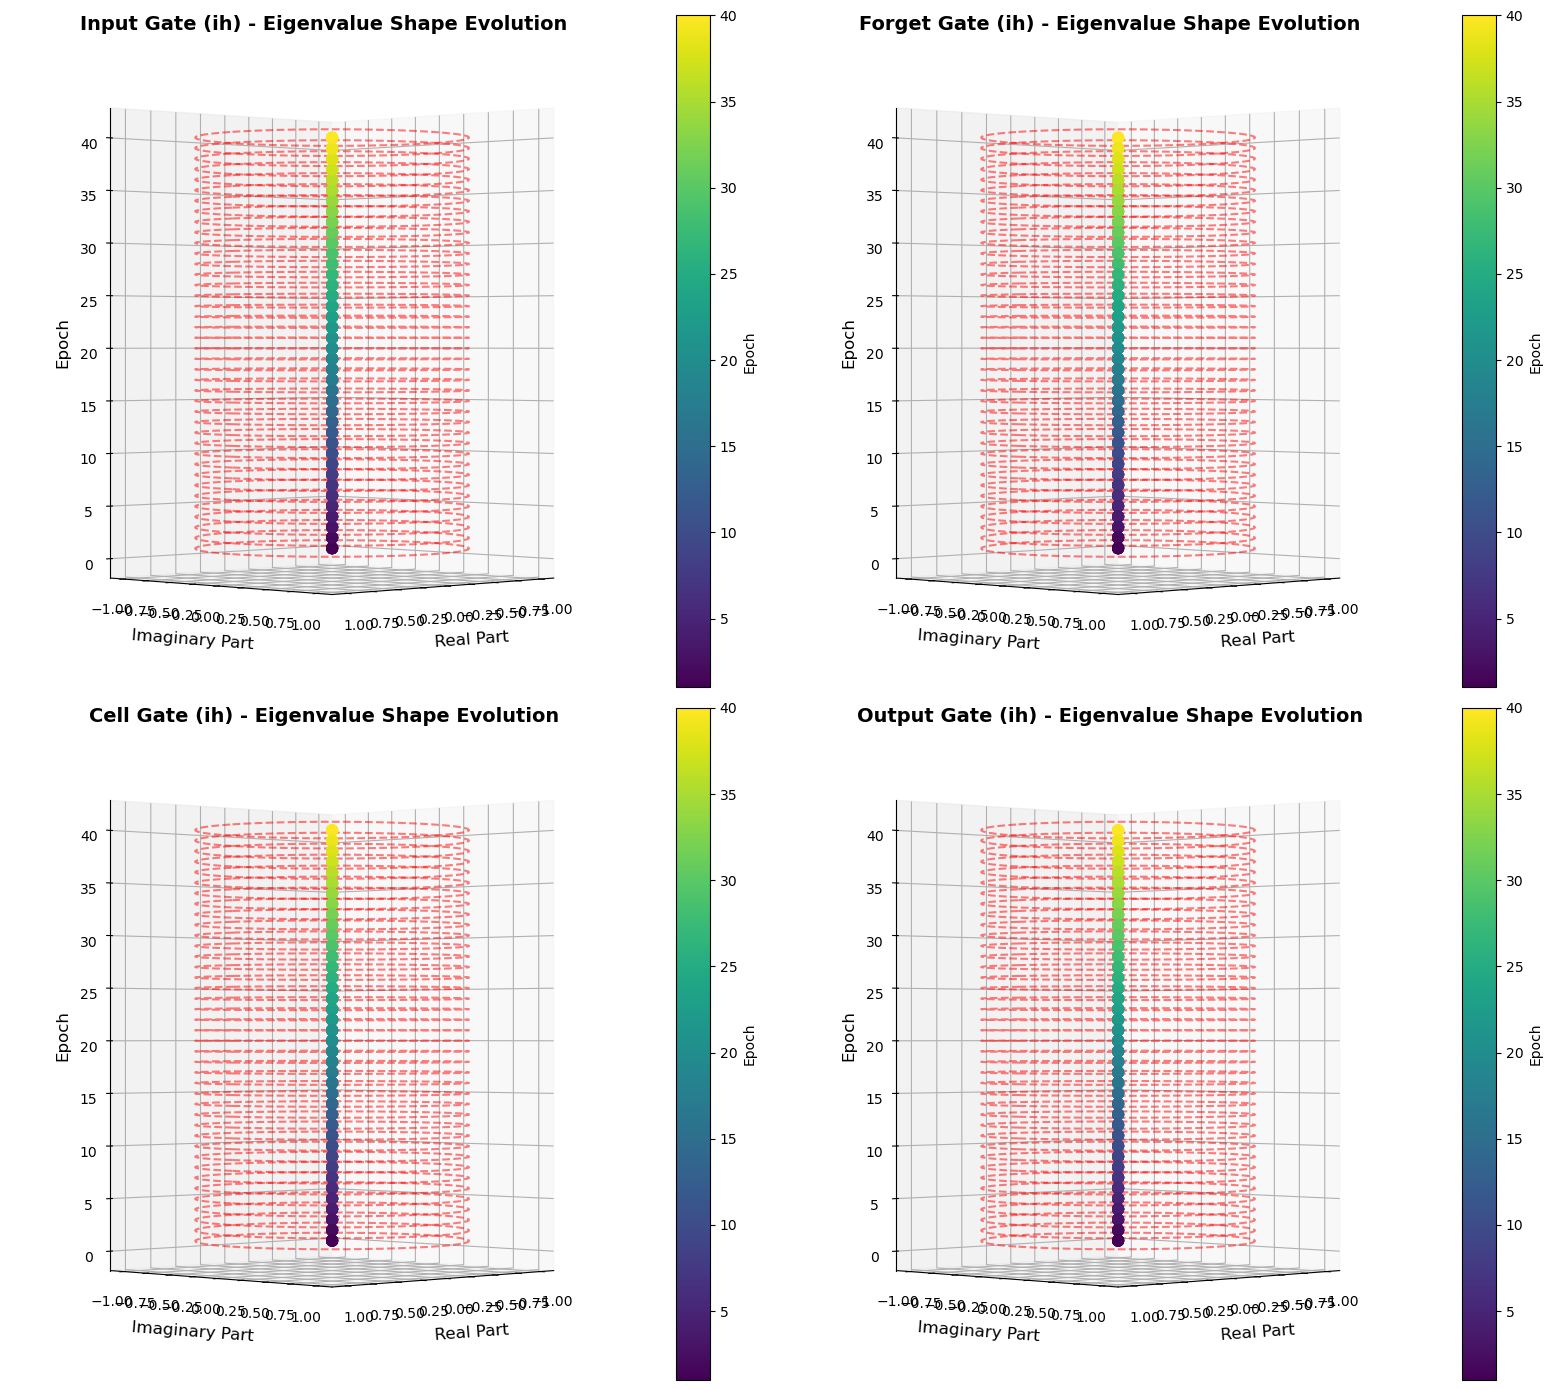

In [41]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_ih_list, gate_names_ih, epochs, top_n=10)


RuntimeError: Error in qhull Delaunay triangulation calculation: singular input data (exitcode=2); use python verbose option (-v) to see original qhull error.

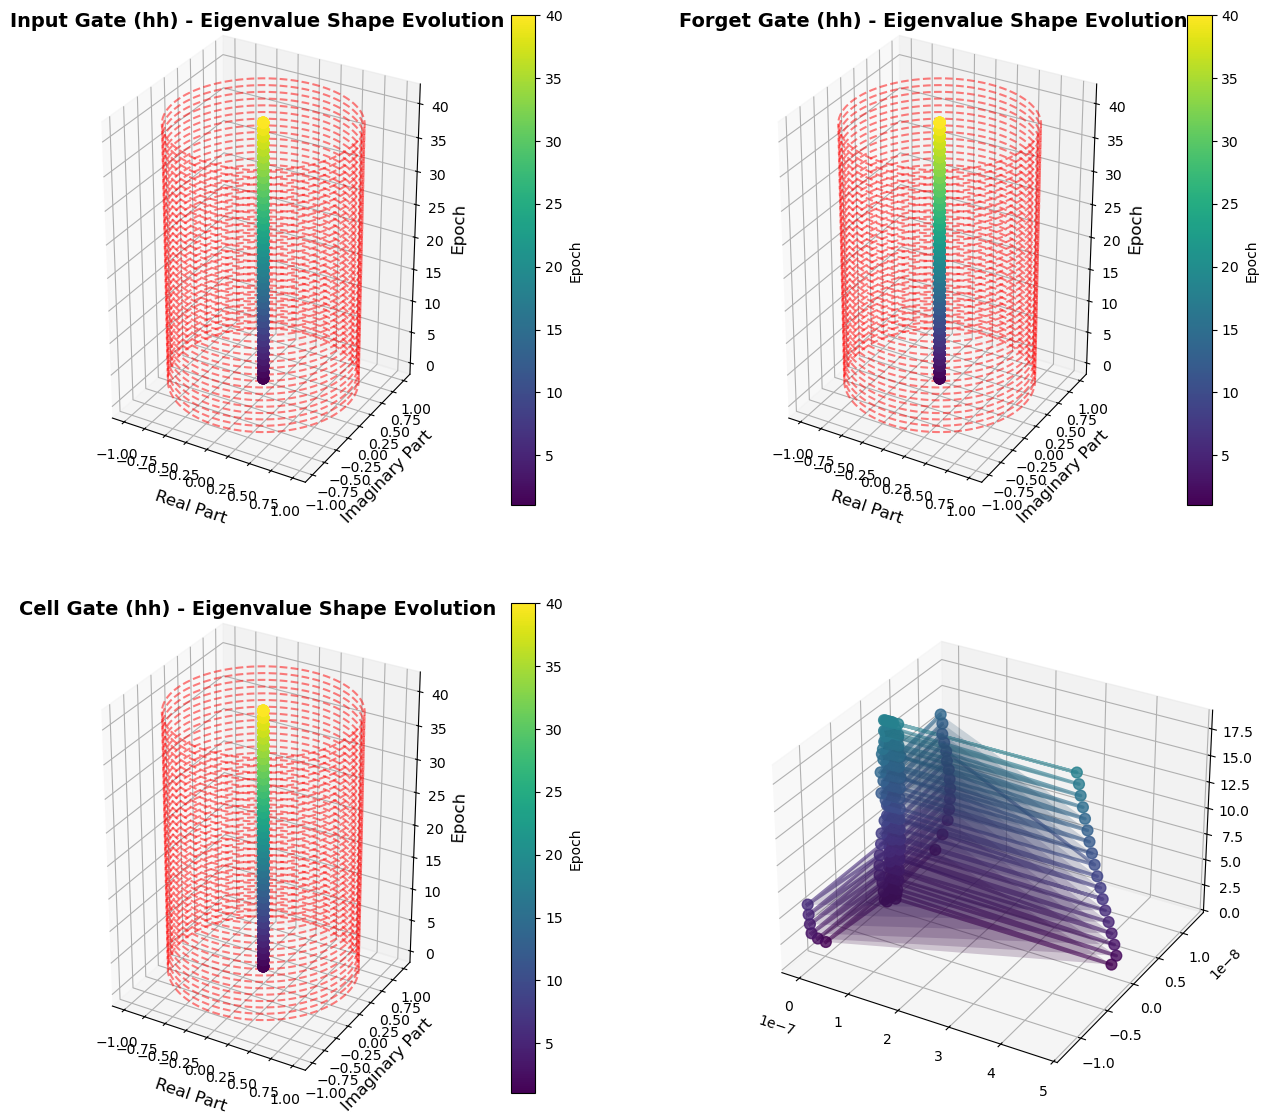

In [42]:
fig = plot_3d_eigenvalue_evolution(eigenvalues_hh_list, gate_names_hh, epochs, top_n=10)
